# SMS Spam Detection

This will automatically classify incoming text messages as either legitimate or spam using machine learning and deep learning models. 

Usage of three Tensorflow models: a dense embedding model, a Bi-LSTM model and a transferlearning model

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

In [6]:
df = pd.read_csv("../data/spam.csv")

df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [10]:
avg_words_len = round(sum([len(i.split())
                          for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


In [15]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision_score': precision_score(y, y_preds),
        'recall_score': recall_score(y, y_preds),
        'f1_score': f1_score(y, y_preds),
    }

In [13]:
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

In [16]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9055 - loss: 0.2804 - val_accuracy: 0.9596 - val_loss: 0.1455
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9776 - loss: 0.0906 - val_accuracy: 0.9758 - val_loss: 0.0771
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9897 - loss: 0.0417 - val_accuracy: 0.9776 - val_loss: 0.0672
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9935 - loss: 0.0248 - val_accuracy: 0.9794 - val_loss: 0.0667
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9966 - loss: 0.0171 - val_accuracy: 0.9803 - val_loss: 0.0640


In [ ]:
# this variant stacks two bidirection LSTM layers to capture context from both past and present
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x) # flatten final sequence befor feeding into dense layers
x = layers.Dropout(0.1)(x) # reduce overfitting
x = layers.Dense(32, activation='relu')(x) # dense hidden layer with ReLU and a sigmoid ouptu layer for classification
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9473 - loss: 0.1716 - val_accuracy: 0.9749 - val_loss: 0.0825
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9899 - loss: 0.0324 - val_accuracy: 0.9722 - val_loss: 0.0727
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9975 - loss: 0.0086 - val_accuracy: 0.9713 - val_loss: 0.1013
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9975 - loss: 0.0067 - val_accuracy: 0.9767 - val_loss: 0.1061
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9984 - loss: 0.0046 - val_accuracy: 0.9758 - val_loss: 0.1120


In [ ]:
# load a pretrained USE from Tensorflow Hub
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False, # use it purely as a feature extractor
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer) # Lambda layer to call USE and produce a fixed 512-dimensional sentence embedding
x = layers.Dense(64, activation='relu')(embedding) 
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x) # single sigmoid unit for spam vs ham prediction
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9172 - loss: 0.2994 - val_accuracy: 0.9695 - val_loss: 0.1108
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9787 - loss: 0.0807 - val_accuracy: 0.9803 - val_loss: 0.0691
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9823 - loss: 0.0571 - val_accuracy: 0.9821 - val_loss: 0.0579
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9854 - loss: 0.0472 - val_accuracy: 0.9839 - val_loss: 0.0538
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9895 - loss: 0.0399 - val_accuracy: 0.9830 - val_loss: 0.0525


In [19]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance: ")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step
Performance: 
                   accuracy  precision_score  recall_score  f1_score
Dense Embedding    0.980269         0.970370      0.879195  0.922535
Bi-LSTM            0.975785         0.917808      0.899329  0.908475
Transfer Learning  0.982960         0.951389      0.919463  0.935154


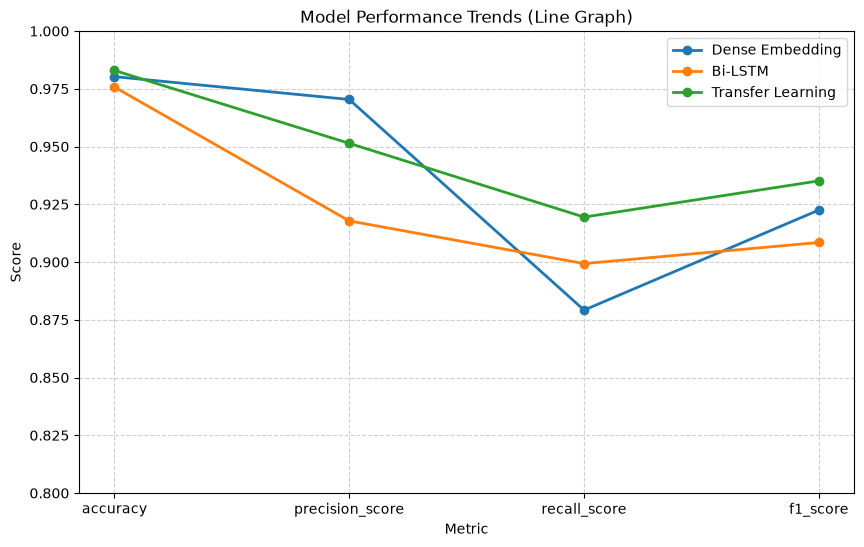

In [ ]:
plt.figure(figsize=(10, 6))
for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()